In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = pd.read_csv("SILKYSKY_DATA_CW2 (F).csv",encoding='latin1')

In [5]:
df.head()

,Ref,id,Gender,Satisfied,Age,Age Band,Type of Travel,Class,Flight Distance,Destination,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,0,70172,Male,Y,13,Under 18,Personal Travel,Eco Plus,4760,India,...,5,5,4,3,4,4,5,5,25,18.0
1,1,5047,Male,N,25,25 to 34,Business travel,Business,235,Republic of Ireland,...,1,1,1,5,3,1,4,1,1,6.0
2,2,110028,Female,Y,26,25 to 34,Business travel,Business,4760,India,...,5,5,4,3,4,4,4,5,0,0.0
3,3,24026,Female,Y,25,25 to 34,Business travel,Business,560,Norway,...,2,2,2,5,3,1,4,2,11,9.0
4,4,119299,Male,Y,61,55 to 64,Business travel,Business,4760,India,...,5,3,3,4,4,3,3,3,0,0.0


In [6]:
df.columns

Index(['Ref', 'id', 'Gender', 'Satisfied', 'Age', 'Age Band', 'Type of Travel',
       'Class', 'Flight Distance', 'Destination', 'Continent',
       'Inflight wifi service', 'Departure/Arrival time convenient',
       'Ease of Online booking', 'Gate location', 'Food and drink',
       'Online boarding', 'Seat comfort', 'Inflight entertainment',
       'On-board service', 'Leg room service', 'Baggage handling',
       'Checkin service', 'Inflight service', 'Cleanliness',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 27 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Ref                                103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Satisfied                          103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Age Band                           103904 non-null  object 
 6   Type of Travel                     103904 non-null  object 
 7   Class                              103904 non-null  object 
 8   Flight Distance                    103904 non-null  int64  
 9   Destination                        103904 non-null  object 
 10  Continent                          103904 non-null  object 
 11  Inflight wifi service              1039

In [9]:
df.shape

(103904, 27)

In [10]:
df.isnull().sum()

Ref                                    0
id                                     0
Gender                                 0
Satisfied                              0
Age                                    0
Age Band                               0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Destination                            0
Continent                              0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness     

In [14]:
df = df.dropna()

In [15]:
df.isnull().sum()

Ref                                  0
id                                   0
Gender                               0
Satisfied                            0
Age                                  0
Age Band                             0
Type of Travel                       0
Class                                0
Flight Distance                      0
Destination                          0
Continent                            0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minute

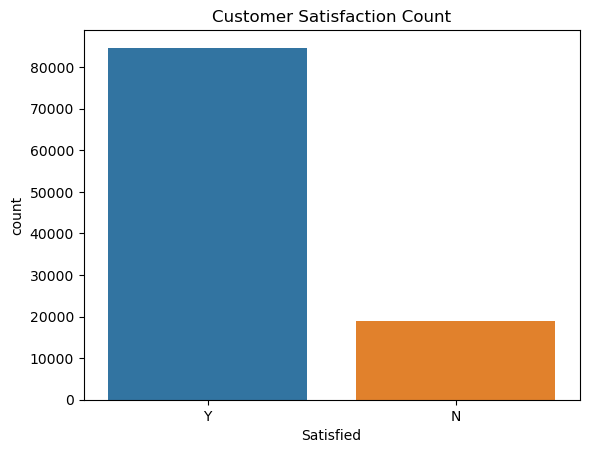

In [16]:
sns.countplot(x='Satisfied', data=df)
plt.title('Customer Satisfaction Count')
plt.show()


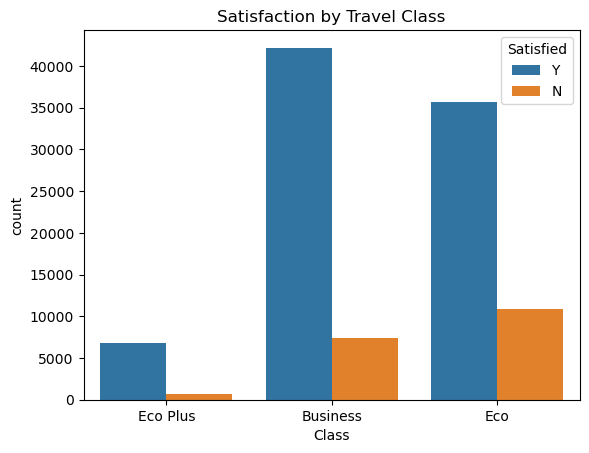

In [17]:
sns.countplot(x='Class', hue='Satisfied', data=df)
plt.title('Satisfaction by Travel Class')
plt.show()


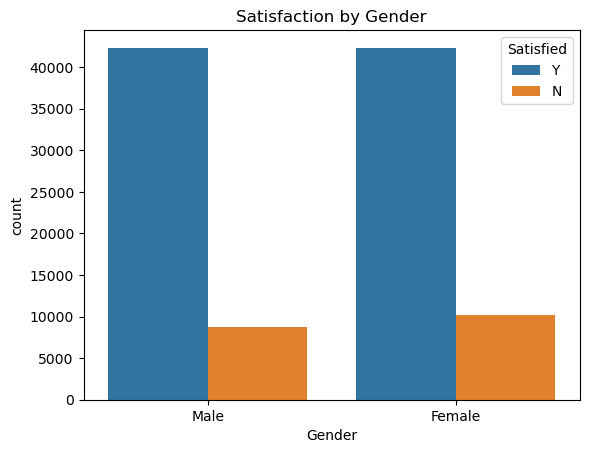

In [18]:
sns.countplot(x='Gender', hue='Satisfied', data=df)
plt.title('Satisfaction by Gender')
plt.show()


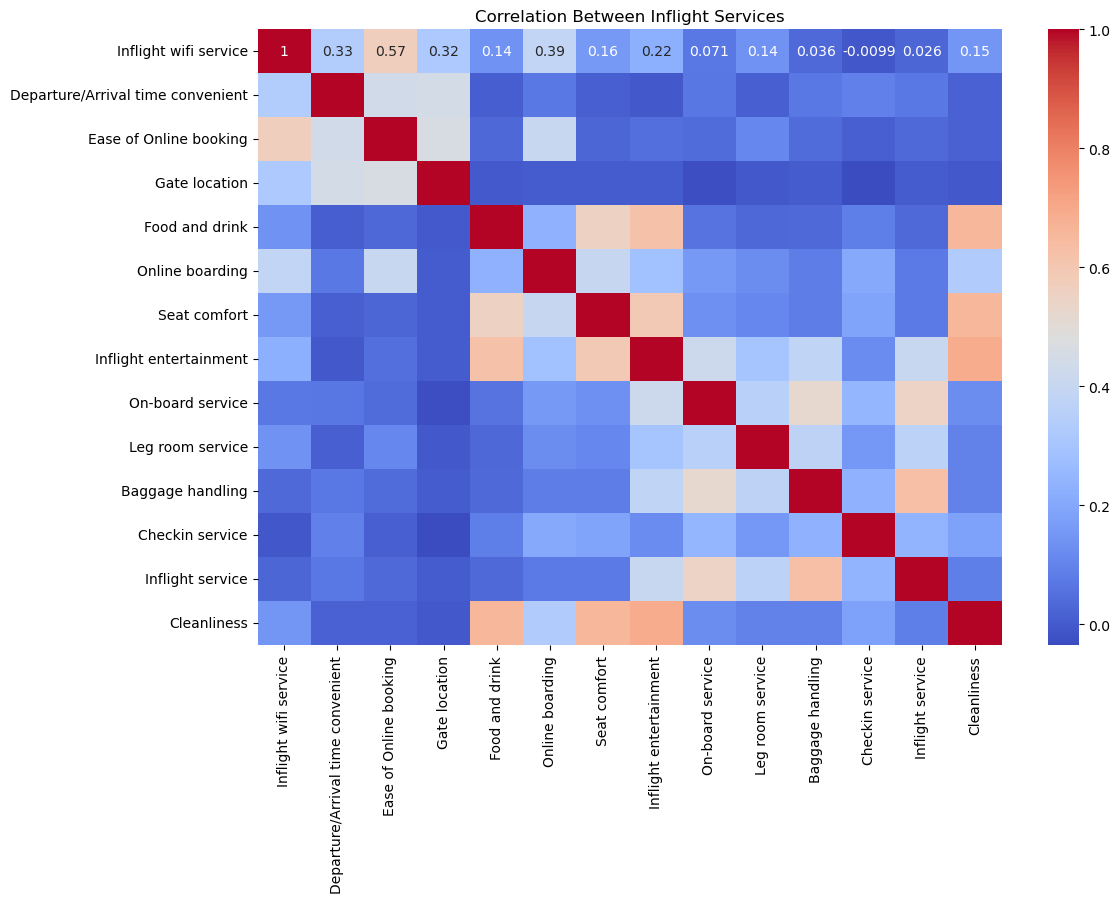

In [19]:
cols = df.columns[11:25]  # rating columns
plt.figure(figsize=(12,8))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Inflight Services')
plt.show()


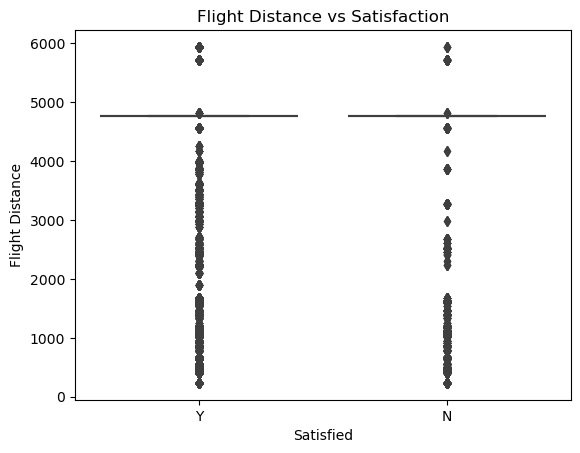

In [20]:
sns.boxplot(x='Satisfied', y='Flight Distance', data=df)
plt.title('Flight Distance vs Satisfaction')
plt.show()


In [21]:
df['Class'].value_counts()


Class
Business    49533
Eco         46593
Eco Plus     7468
Name: count, dtype: int64

In [22]:
df.groupby('Class')['Satisfied'].value_counts(normalize=True) * 100


Class     Satisfied
Business  Y            85.173521
          N            14.826479
Eco       Y            76.653145
          N            23.346855
Eco Plus  Y            90.452598
          N             9.547402
Name: proportion, dtype: float64

In [24]:
rating_cols = df.columns[11:25]
df[rating_cols].mean().sort_values(ascending=False)

Inflight service                     3.640665
Baggage handling                     3.631562
Seat comfort                         3.399068
On-board service                     3.382493
Inflight entertainment               3.358254
Leg room service                     3.351275
Checkin service                      3.304216
Cleanliness                          3.286291
Online boarding                      3.250372
Food and drink                       3.202019
Departure/Arrival time convenient    3.060032
Gate location                        2.976968
Ease of Online booking               2.756936
Inflight wifi service                2.522221
dtype: float64

In [25]:
df.groupby('Type of Travel')['Flight Distance'].mean()


Type of Travel
Business travel    4189.898412
Personal Travel    4106.723832
Name: Flight Distance, dtype: float64

In [26]:
df.groupby('Satisfied')[['Departure Delay in Minutes', 'Arrival Delay in Minutes']].mean()

,Departure Delay in Minutes,Arrival Delay in Minutes
Satisfied,,
N,15.316398,15.783575
Y,14.624198,15.046563


In [28]:
df[df['Satisfied'] == 'Y']['Destination'].value_counts().head(5)

Destination
India                  68438
Italy                    725
United Kingdom           652
Cyprus                   621
Republic of Ireland      598
Name: count, dtype: int64

In [30]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Satisfied'] = le.fit_transform(df['Satisfied'])  # Y=1, N=0

C:\Users\USER-PC\AppData\Local\Temp\ipykernel_13292\858561689.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Satisfied'] = le.fit_transform(df['Satisfied'])  # Y=1, N=0


In [31]:
features = df.columns[11:25]  # service ratings
X = df[features]
y = df['Satisfied']


In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)


RandomForestClassifier()

In [34]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.9137506636420677

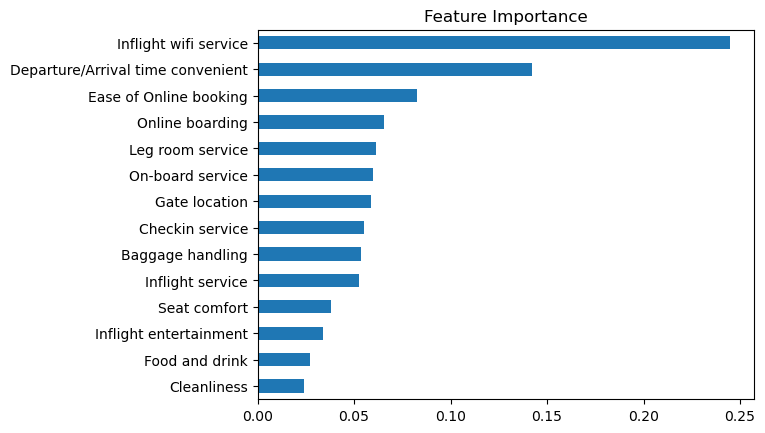

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

feat_imp = pd.Series(model.feature_importances_, index=features)
feat_imp.sort_values().plot(kind='barh', title='Feature Importance')
plt.show()